<a href="https://colab.research.google.com/github/ravithreni02/NLP/blob/main/RESEARCH_NFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 pip install transformers torch pandas matplotlib tqdm

In [2]:

import json
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from transformers import pipeline

In [ ]:
LOAD DATA

In [4]:
DATA_PATH = "nft_tweet_emotions.json"   # cleaned text + NRC emotion scores + followers + location

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"Loaded {len(df)} tweets")
print(df.columns.tolist())


Loaded 98267 tweets
['text', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'negative', 'positive', 'sadness', 'surprise', 'trust', 'followers', 'location', 'original']


In [5]:
def nrc_label(row):
    if row["positive"] > row["negative"]:
        return "positive"
    elif row["negative"] > row["positive"]:
        return "negative"
    else:
        return "neutral"

df["nrc_sentiment"] = df.apply(nrc_label, axis=1)

In [ ]:
LOAD FINBERT

In [6]:
finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    truncation=True,
    max_length=128,
    device=0,
    batch_size=32,
)

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
RUN FINBERT IN BATCHES

In [7]:
texts = df["text"].fillna("").tolist()

results = []
BATCH = 64
for i in tqdm(range(0, len(texts), BATCH), desc="FinBERT scoring"):
    batch = texts[i:i + BATCH]
    # guard against empty strings after preprocessing
    batch = [t if t.strip() else "neutral" for t in batch]
    out = finbert(batch)
    results.extend(out)

df["finbert_label"] = [r["label"] for r in results]      # positive / negative / neutral
df["finbert_score"] = [r["score"] for r in results]       # confidence of the predicted label


FinBERT scoring: 100%|██████████| 1536/1536 [3:11:43<00:00,  7.49s/it]


In [8]:
print("\n--- NRC (paper's lexicon rule) sentiment distribution ---")
print(df["nrc_sentiment"].value_counts(normalize=True) * 100)

print("\n--- FinBERT sentiment distribution ---")
print(df["finbert_label"].value_counts(normalize=True) * 100)

agreement = (df["nrc_sentiment"] == df["finbert_label"]).mean()
print(f"\nAgreement rate between NRC lexicon and FinBERT: {agreement:.2%}")

# Confusion matrix between the two approaches
confusion = pd.crosstab(df["nrc_sentiment"], df["finbert_label"])
print("\nConfusion matrix (rows = NRC, cols = FinBERT):")
print(confusion)


--- NRC (paper's lexicon rule) sentiment distribution ---
nrc_sentiment
neutral     45.084311
positive    44.135875
negative    10.779814
Name: proportion, dtype: float64

--- FinBERT sentiment distribution ---
finbert_label
neutral     94.790723
positive     2.908403
negative     2.300874
Name: proportion, dtype: float64

Agreement rate between NRC lexicon and FinBERT: 45.67%

Confusion matrix (rows = NRC, cols = FinBERT):
finbert_label  negative  neutral  positive
nrc_sentiment                             
negative            723     9669       201
neutral             947    42428       928
positive            591    41051      1729


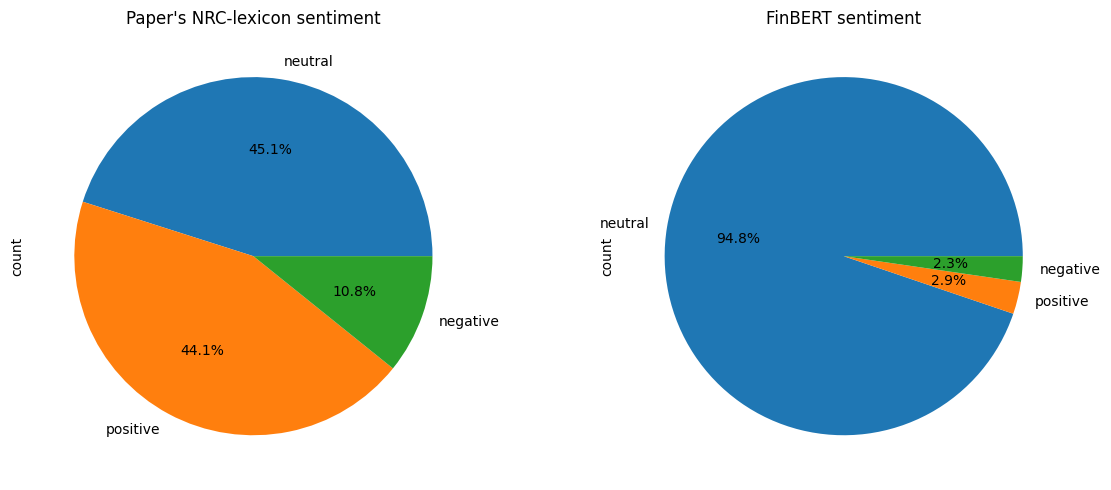

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df["nrc_sentiment"].value_counts().plot.pie(
    autopct="%1.1f%%", ax=axes[0], title="Paper's NRC-lexicon sentiment"
)
df["finbert_label"].value_counts().plot.pie(
    autopct="%1.1f%%", ax=axes[1], title="FinBERT sentiment"
)
plt.tight_layout()
plt.savefig("sentiment_comparison_pie.png", dpi=150)
plt.show()

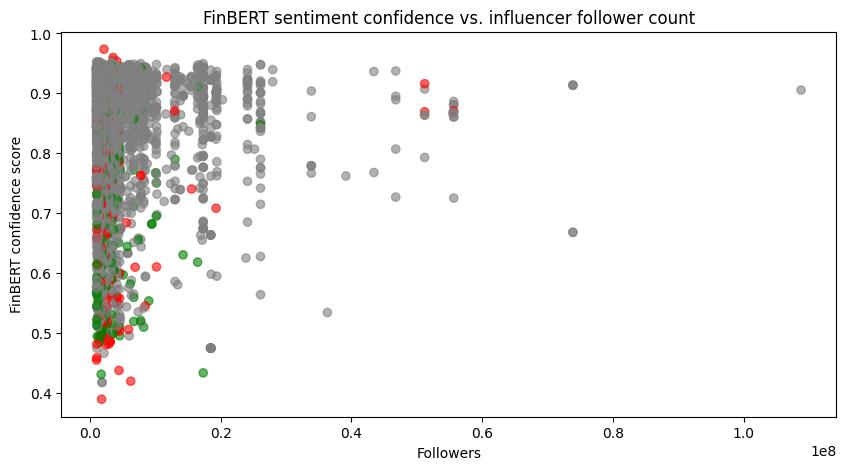

In [10]:
influencers = df[df["followers"] > 1_000_000].copy()
influencers = influencers.sort_values("followers", ascending=False)

plt.figure(figsize=(10, 5))
plt.scatter(
    influencers["followers"],
    influencers["finbert_score"],
    c=influencers["finbert_label"].map({"positive": "green", "negative": "red", "neutral": "gray"}),
    alpha=0.6,
)
plt.xlabel("Followers")
plt.ylabel("FinBERT confidence score")
plt.title("FinBERT sentiment confidence vs. influencer follower count")
plt.savefig("finbert_influencer_analysis.png", dpi=150)
plt.show()


In [11]:
df.to_csv("nft_tweets_with_finbert_sentiment.csv", index=False)
print("\nSaved merged results to nft_tweets_with_finbert_sentiment.csv")



Saved merged results to nft_tweets_with_finbert_sentiment.csv
